In [ ]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")
install.packages("corrplot")
install.packages("reshape2")
install.packages("plotly")
install.packages("readr")
install.packages("gridExtra")
install.packages("readxl")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(corrplot)
library(reshape2)
library(readr)
library(gridExtra)
library(readxl)


In [40]:
library(readr)
sample.data <- read_csv("/content/student_data.csv")

Rows: 500 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Name, Gender, Grade
dbl (8): Student_ID, Study_Hours, Attendance, Assignments, Midterm, Final, P...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [41]:
data <- sample.data

# Standardize column names to be lowercase and snake_case
colnames(data) <- tolower(gsub("([A-Z])", "_\\1", colnames(data)))

# Display the first few rows of the cleaned data
head(data)

_student__i_d,_name,_gender,_study__hours,_attendance,_assignments,_midterm,_final,_project,_total,_grade
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Riya,F,2,75,60,55,58,65,313,A
2,Priya,M,5,88,78,70,75,80,391,A
3,Reena,F,8,101,96,85,92,95,469,A
4,Riya,F,11,114,114,100,109,110,547,A
5,Priya,M,14,127,132,115,126,125,625,A
6,Reena,F,17,140,150,130,143,140,703,A


In [42]:
tail(data)

_student__i_d,_name,_gender,_study__hours,_attendance,_assignments,_midterm,_final,_project,_total,_grade
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
495,Reena,F,1484,6497,8952,7465,8456,7475,38845,B
496,Riya,F,1487,6510,8970,7480,8473,7490,38923,B
497,Priya,M,1490,6523,8988,7495,8490,7505,39001,A
498,Reena,F,1493,6536,9006,7510,8507,7520,39079,A
499,Riya,F,1496,6549,9024,7525,8524,7535,39157,A
500,Priya,M,1499,6562,9042,7540,8541,7550,39235,A


In [43]:
summary(data)

 _student__i_d      _name             _gender          _study__hours   
 Min.   :  1.0   Length:500         Length:500         Min.   :   2.0  
 1st Qu.:125.8   Class :character   Class :character   1st Qu.: 376.2  
 Median :250.5   Mode  :character   Mode  :character   Median : 750.5  
 Mean   :250.5                                         Mean   : 750.5  
 3rd Qu.:375.2                                         3rd Qu.:1124.8  
 Max.   :500.0                                         Max.   :1499.0  
  _attendance    _assignments     _midterm        _final        _project   
 Min.   :  75   Min.   :  60   Min.   :  55   Min.   :  58   Min.   :  65  
 1st Qu.:1697   1st Qu.:2306   1st Qu.:1926   1st Qu.:2179   1st Qu.:1936  
 Median :3318   Median :4551   Median :3798   Median :4300   Median :3808  
 Mean   :3318   Mean   :4551   Mean   :3798   Mean   :4300   Mean   :3808  
 3rd Qu.:4940   3rd Qu.:6796   3rd Qu.:5669   3rd Qu.:6420   3rd Qu.:5679  
 Max.   :6562   Max.   :9042   Max.   :7

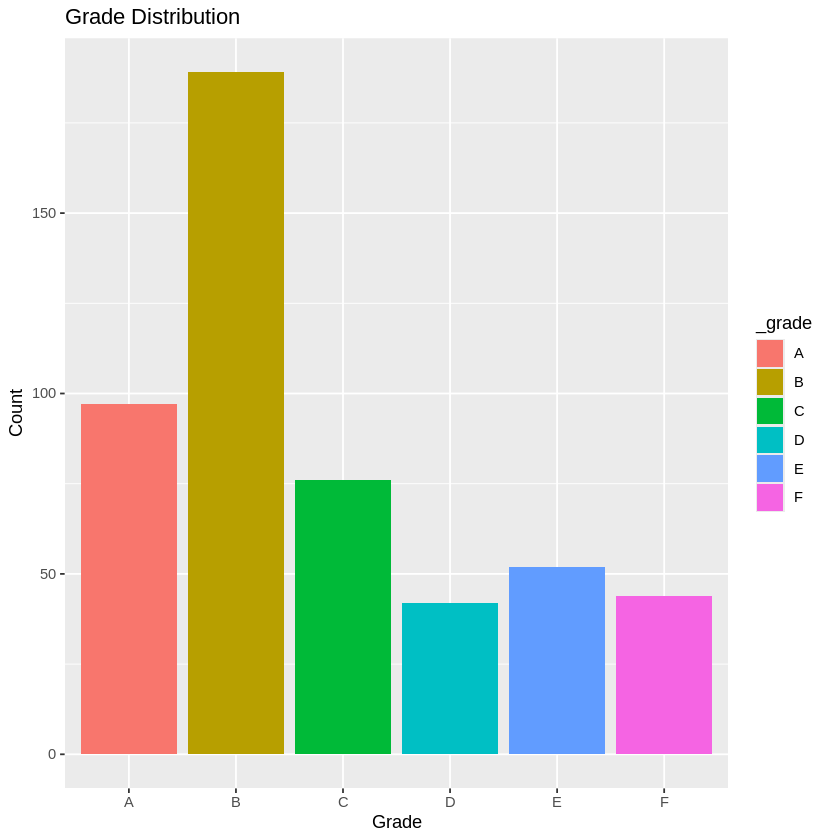

In [44]:
ggplot(data, aes(x = `_grade`, fill = `_grade`)) +
  geom_bar() +
  ggtitle("Grade Distribution") +
  xlab("Grade") +
  ylab("Count")

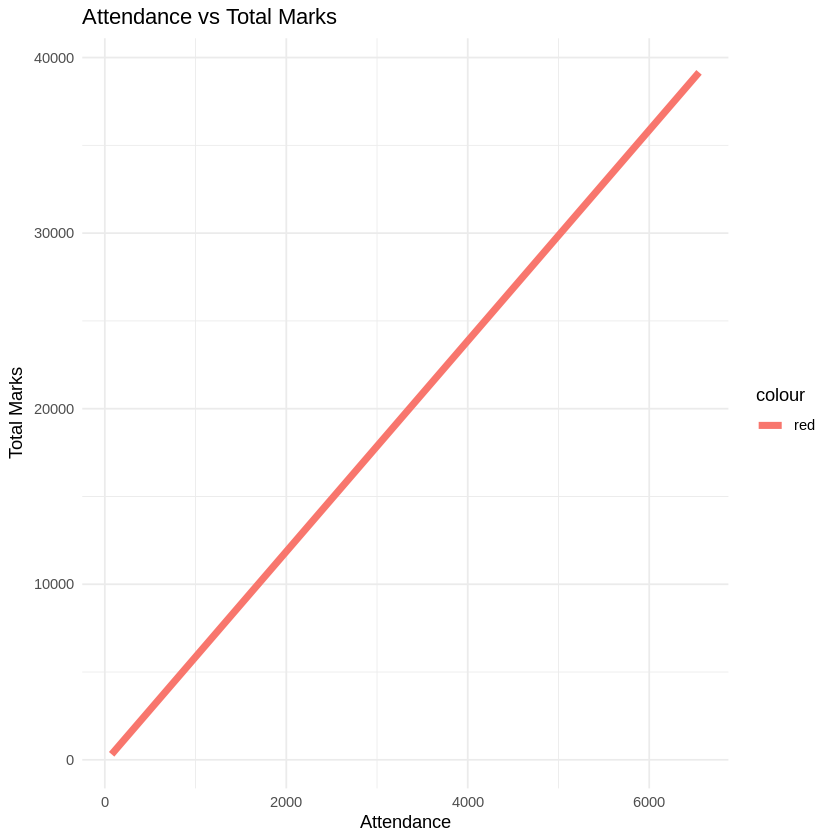

In [ ]:
ggplot(data, aes(x = `_attendance`, y = `_total`,color="red")) +
  geom_line(size = 2) +
  labs(title = "Attendance vs Total Marks",
       x = "Attendance", y = "Total Marks") +
  theme_minimal()

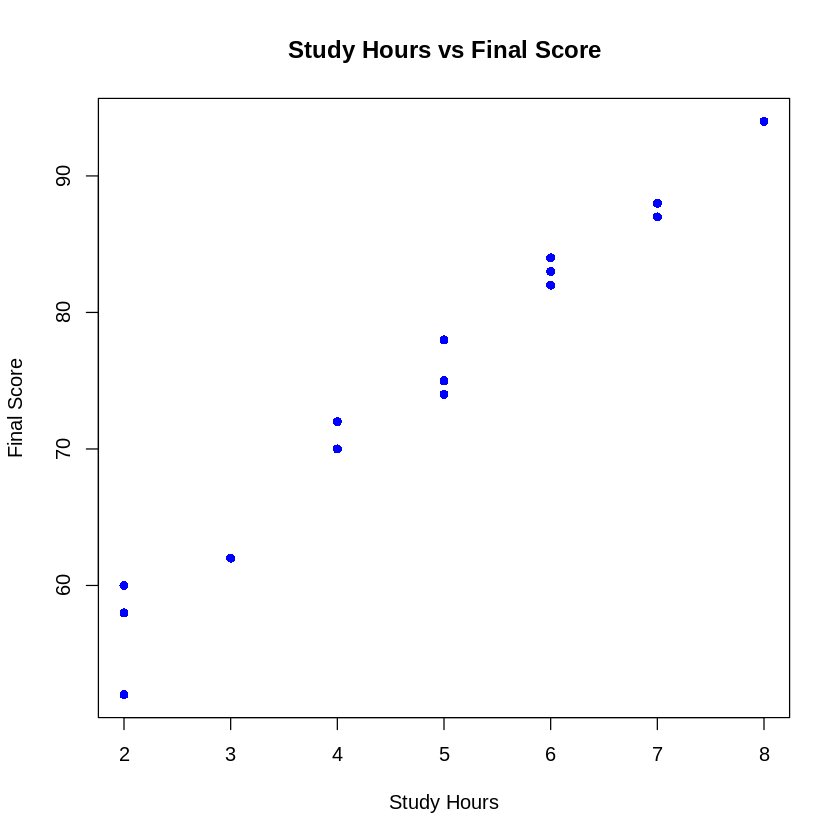

In [ ]:
plot(data$`_study__hours`, data$`_final`,
     main="Study Hours vs Final Score",
     xlab="Study Hours",
     ylab="Final Score",
     pch=16,
     col = "blue")



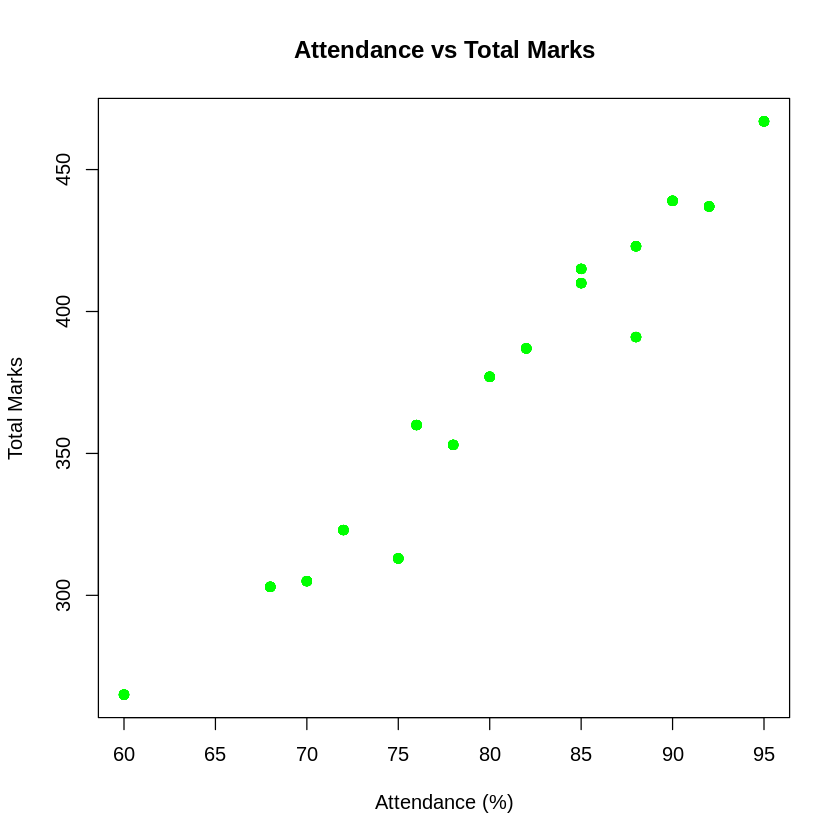

In [ ]:
plot(data$`_attendance`, data$`_total`,
     main = "Attendance vs Total Marks",
     xlab = "Attendance (%)",
     ylab = "Total Marks",
     col = "green",
     pch = 19)

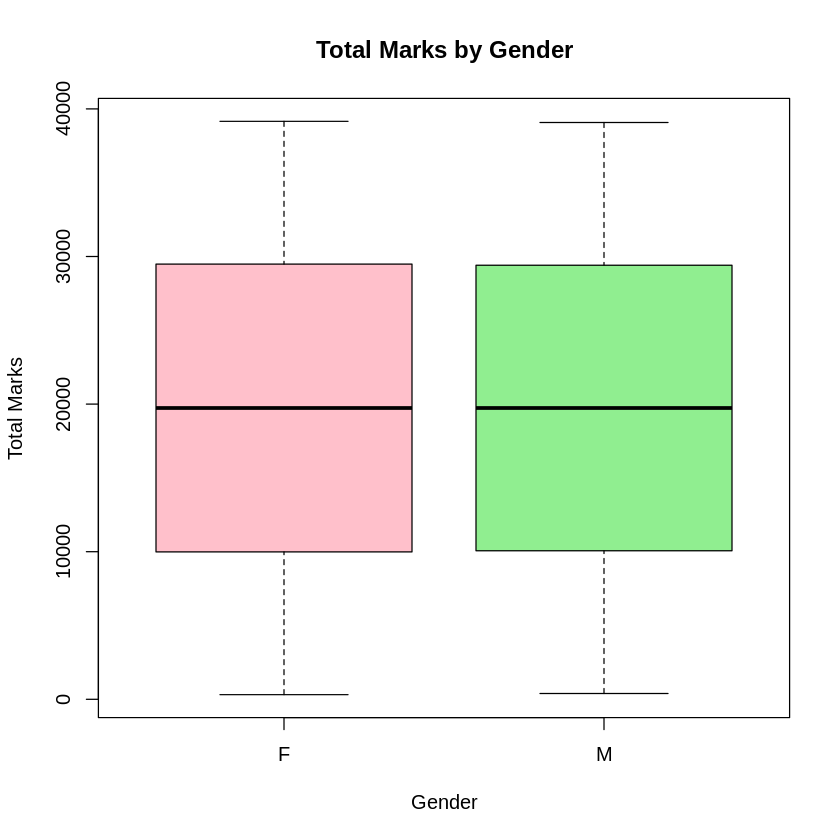

In [ ]:
boxplot(`_total` ~ `_gender`, data=data,
        main="Total Marks by Gender",
        xlab="Gender",
        ylab="Total Marks",
        col=c("pink","lightgreen"))

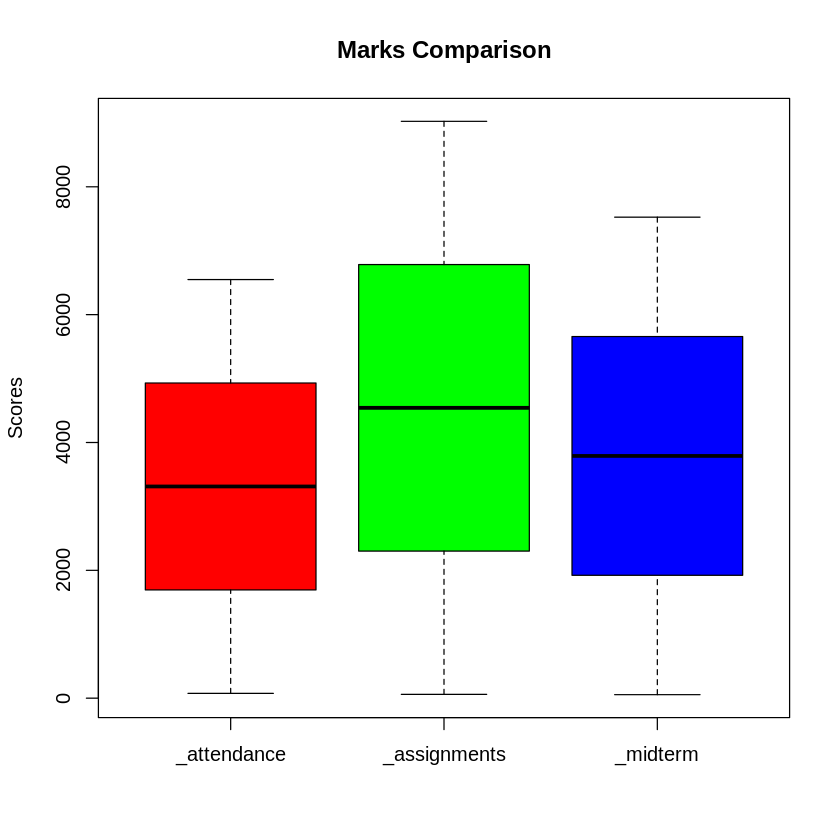

In [ ]:
boxplot(data[,5:7],
        col = c("red","green","blue"),
        main = "Marks Comparison",
        ylab = "Scores")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



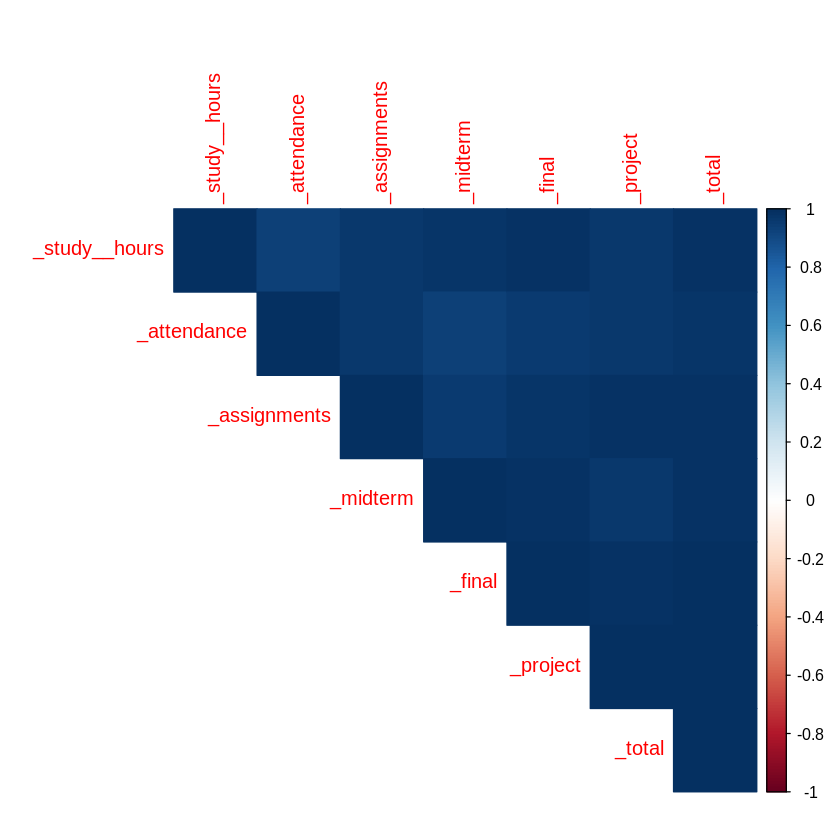

In [ ]:
library(dplyr)
install.packages("corrplot")
library(corrplot)

# Re-initialize 'data' and standardize column names to ensure it's a dataframe
data <- sample.data
colnames(data) <- tolower(gsub("([A-Z])", "_\\1", colnames(data)))

numeric_data <- data %>%
  select(`_study__hours`, `_attendance`, `_assignments`, `_midterm`, `_final`, `_project`, `_total`)

cor_matrix <- cor(numeric_data)

corrplot(cor_matrix, method = "color", type = "upper")

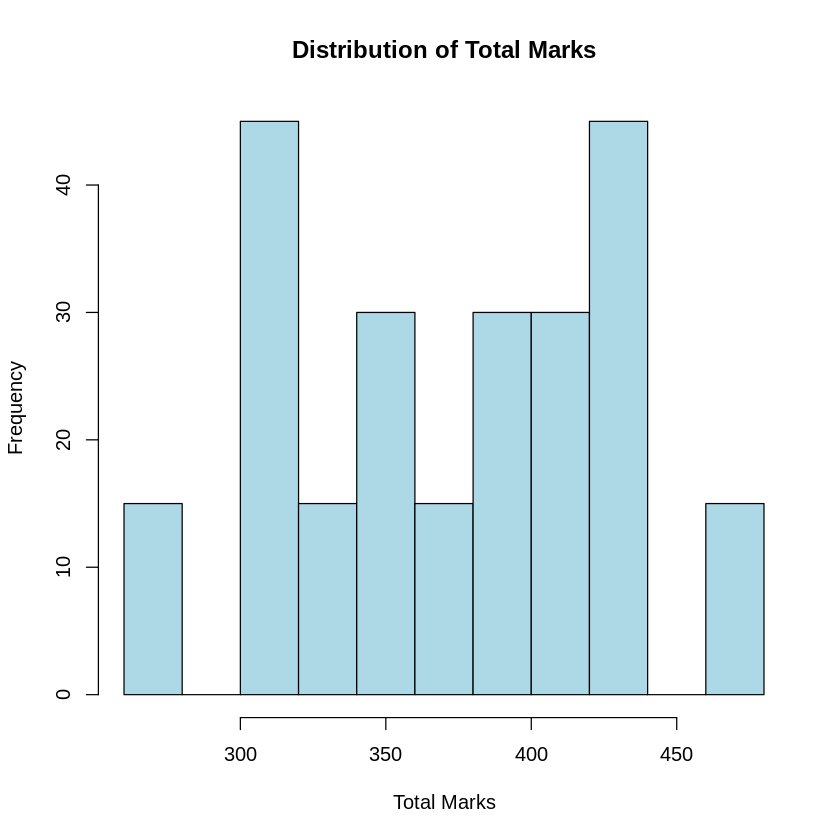

In [ ]:
hist(data$`_total`,
     main="Distribution of Total Marks",
     xlab="Total Marks",
     col="lightblue",
     border="black")

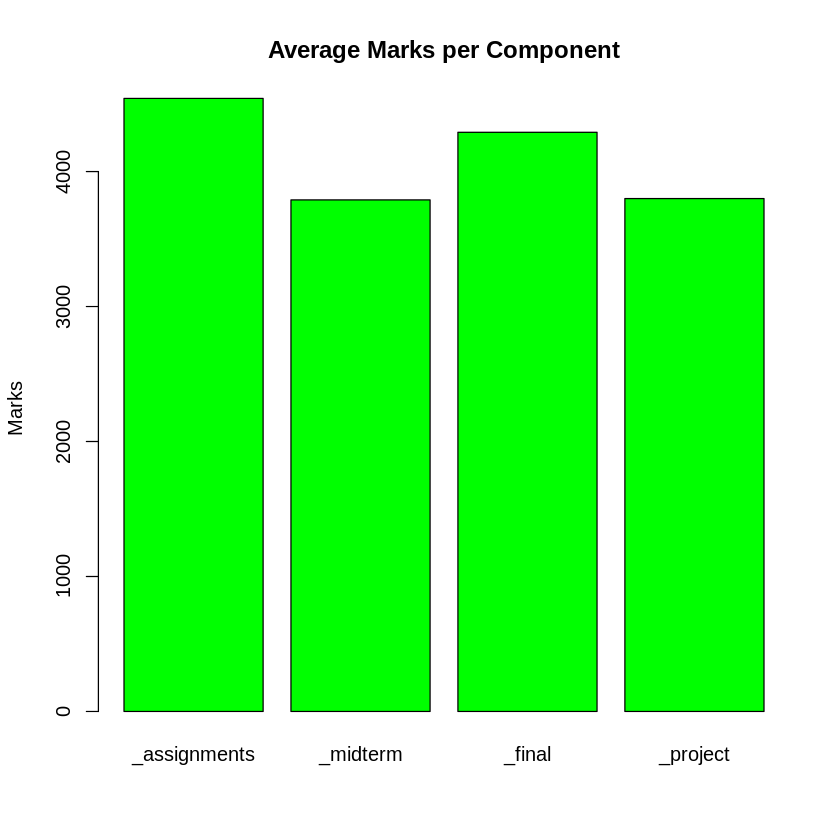

In [ ]:
avg_marks <- colMeans(data[, c("_assignments", "_midterm", "_final", "_project")], na.rm = TRUE)

barplot(avg_marks,
        col = "green",
        main = "Average Marks per Component",
        ylab = "Marks")

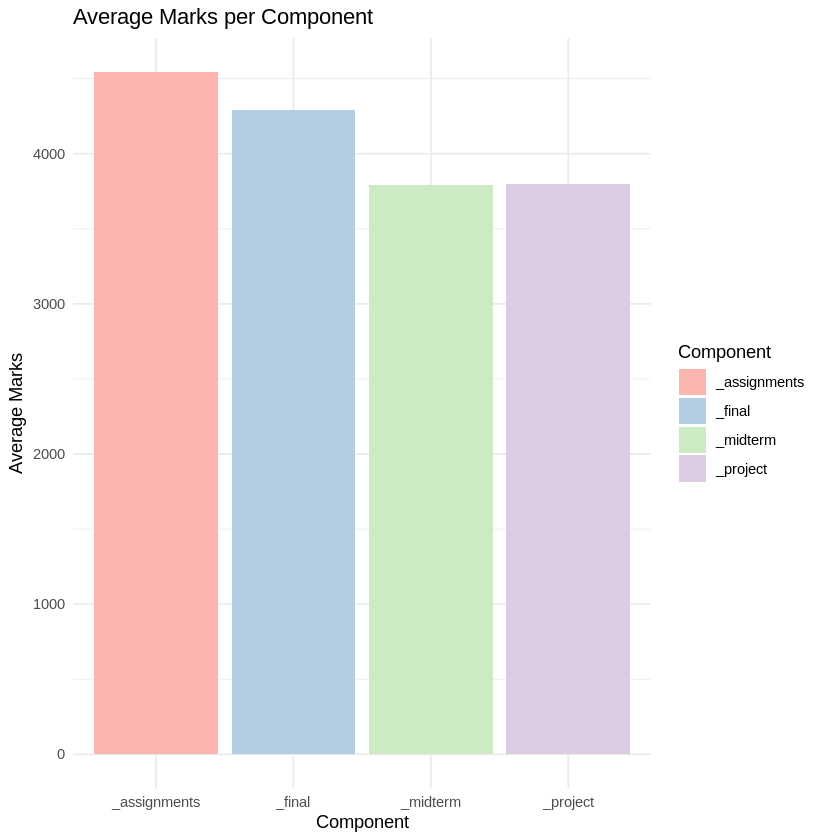

In [ ]:
library(reshape2)

avg_data <- colMeans(data[, c("_assignments", "_midterm", "_final", "_project")], na.rm = TRUE)
avg_df <- data.frame(Component = names(avg_data), Average = avg_data)

ggplot(avg_df, aes(x = Component, y = Average, fill = Component)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Average Marks per Component",
       x = "Component",
       y = "Average Marks") +
  scale_fill_brewer(palette = "Pastel1")

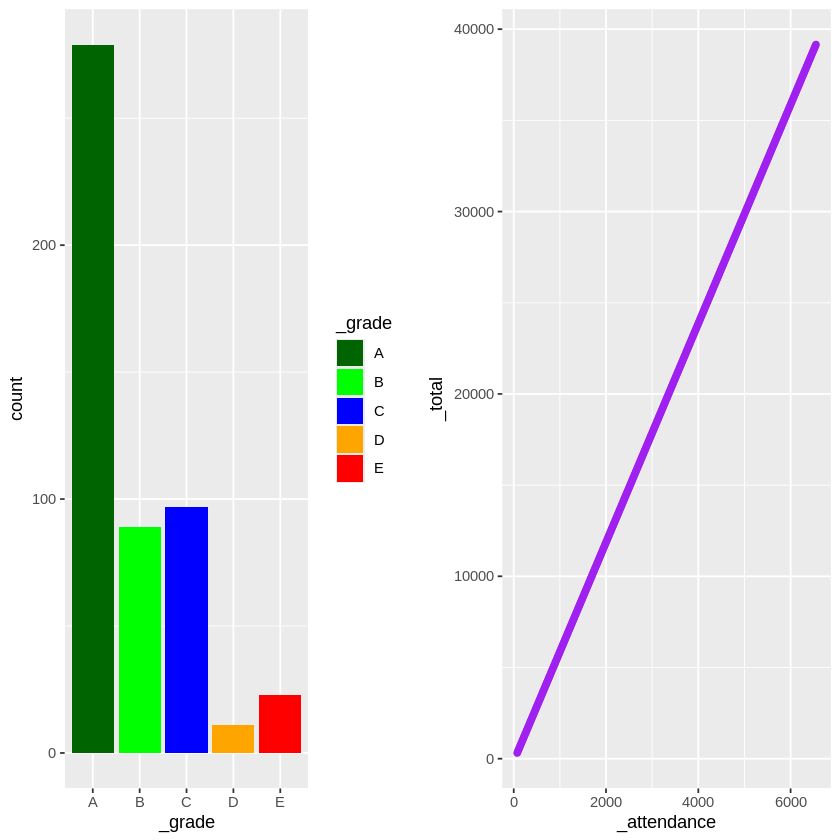

In [ ]:
data$`_grade` <- factor(data$`_grade`, levels = c("A", "B", "C", "D", "E"))

p1 <- ggplot(data, aes(x=`_grade`, fill=`_grade`)) +
  geom_bar() +
  scale_fill_manual(values=c("A"="darkgreen","B"="green","C"="blue","D"="orange","E"="red"))

p2 <- ggplot(data, aes(x=`_attendance`, y=`_total`)) +
  geom_point(color="purple")

grid.arrange(p1, p2,  ncol=2)

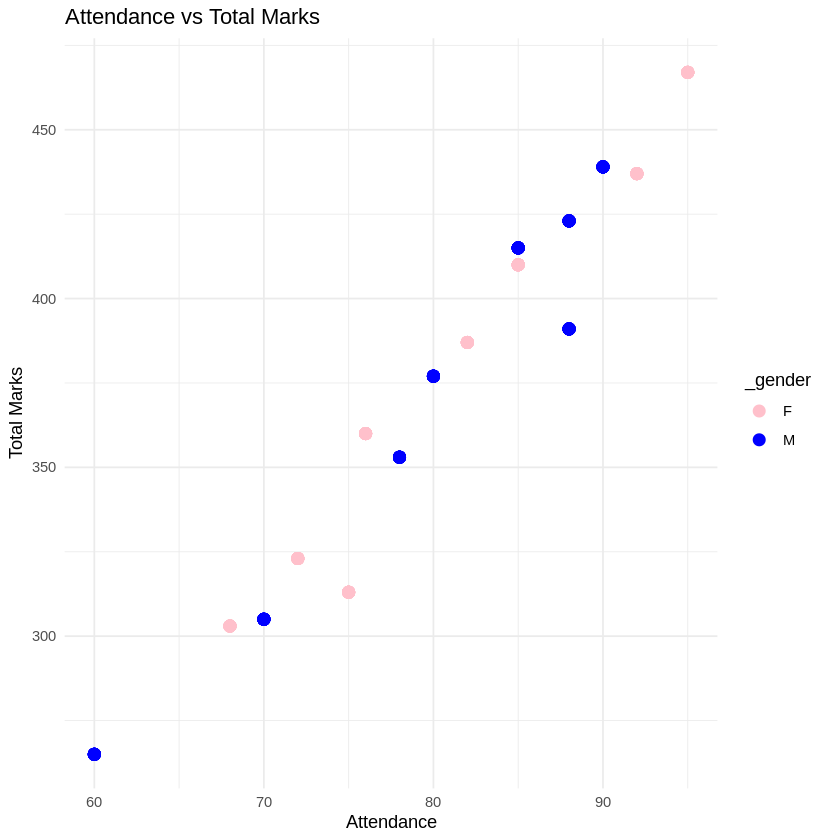

In [ ]:
library(ggplot2)
ggplot(data, aes(x = `_attendance`, y = `_total`, color = `_gender`)) +
  geom_point(size = 3) +
  scale_color_manual(values = c("M"="blue", "F"="pink")) +
  labs(title = "Attendance vs Total Marks",
       x = "Attendance", y = "Total Marks") +
  theme_minimal()

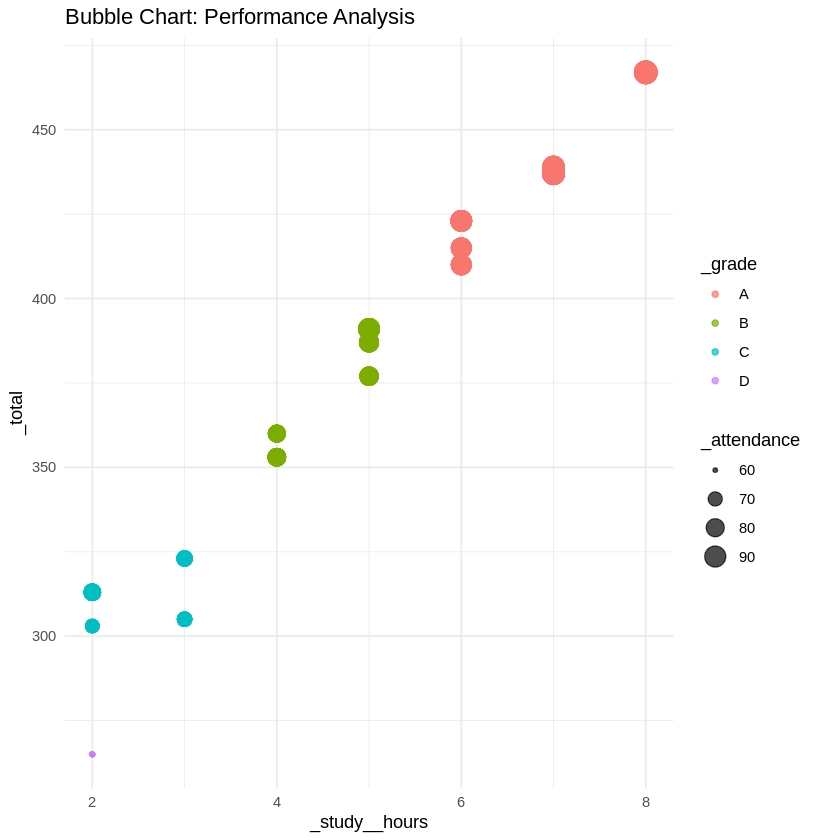

In [ ]:
library(ggplot2)
ggplot(data, aes(x = `_study__hours`, y = `_total`,
                         size = `_attendance`,
                         color = `_grade`)) +
  geom_point(alpha = 0.7) +
  labs(title = "Bubble Chart: Performance Analysis") +
  theme_minimal()

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



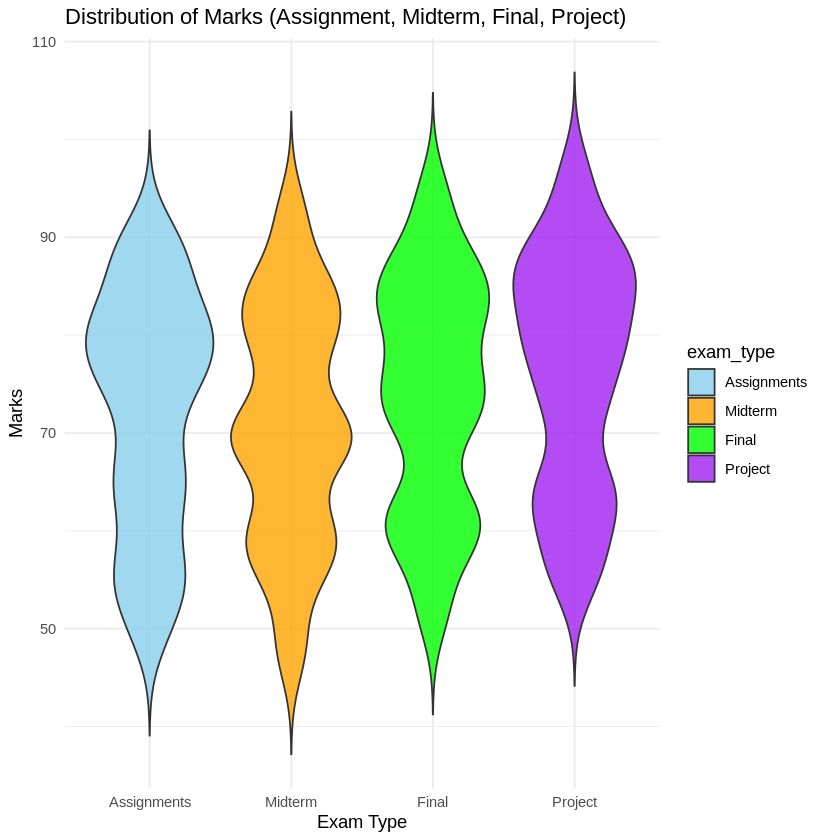

In [ ]:
library(ggplot2)
install.packages("reshape2", quietly = TRUE)
library(reshape2)
library(dplyr)

# Re-initialize 'data' and standardize column names to ensure it's a dataframe
data <- sample.data
colnames(data) <- tolower(gsub("([A-Z])", "_\\1", colnames(data)))

# Melt the data to long format for plotting exam scores
long_data <- melt(data,
                  id.vars = c("_student__i_d", "_name", "_gender", "_study__hours", "_attendance", "_grade", "_total"),
                  measure.vars = c("_assignments", "_midterm", "_final", "_project"),
                  variable.name = "exam_type",
                  value.name = "marks")

# Rename exam_type levels for better readability in the plot
long_data$exam_type <- factor(long_data$exam_type,
                              levels = c("_assignments", "_midterm", "_final", "_project"),
                              labels = c("Assignments", "Midterm", "Final", "Project"))

# Now the ggplot code can be executed with correct column names
ggplot(long_data, aes(x = exam_type, y = marks, fill = exam_type)) +
  geom_violin(trim = FALSE, alpha = 0.8) +
  scale_fill_manual(values = c(
    "Assignments" = "skyblue",
    "Midterm" = "orange",
    "Final" = "green",
    "Project" = "purple"
  )) +
  labs(
    title = "Distribution of Marks (Assignment, Midterm, Final, Project)",
    x = "Exam Type",
    y = "Marks"
  ) +
  theme_minimal()

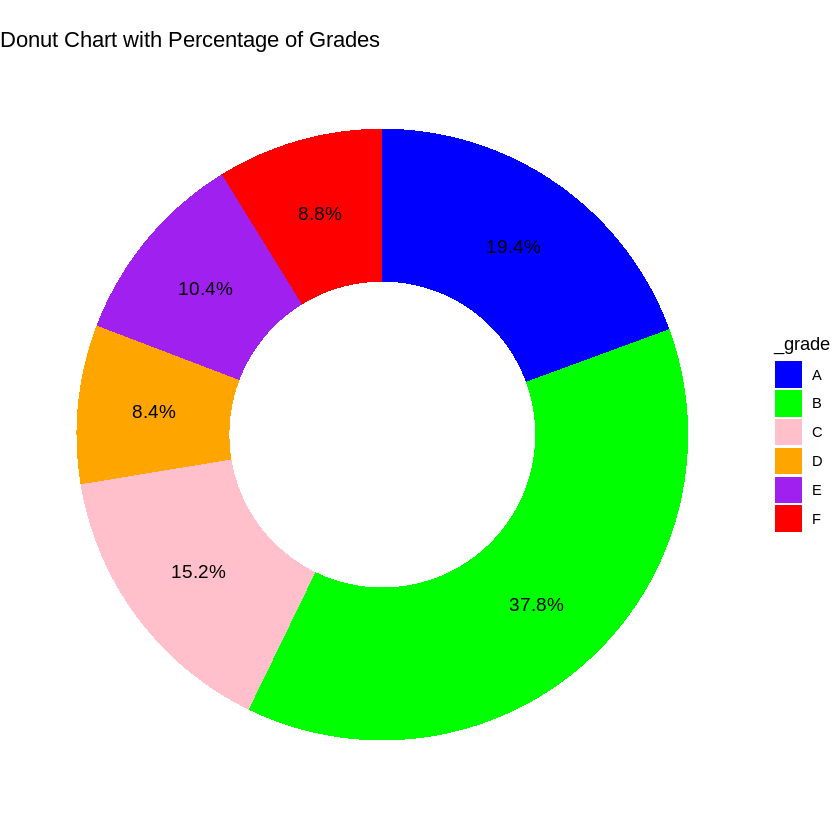

In [50]:
grade_count <- data %>%
  count(`_grade`)

grade_count$fraction <- grade_count$n / sum(grade_count$n)
grade_count$percentage <- paste0(round(grade_count$fraction * 100, 1), "%")

grade_count$ymax <- cumsum(grade_count$fraction)
grade_count$ymin <- c(0, head(grade_count$ymax, -1))

grade_count$label_pos <- (grade_count$ymax + grade_count$ymin) / 2

ggplot(grade_count, aes(ymax = ymax, ymin = ymin,
                        xmax = 4, xmin = 3,
                        fill = `_grade`)) +
  geom_rect() +
  coord_polar(theta = "y") +
  xlim(c(2, 4)) +
  geom_text(aes(x = 3.5, y = label_pos,
                label = percentage),
            color = "black", size = 4) +
  scale_fill_manual(values = c(
    "D"="orange","C"="pink","E"="purple","F"="red",
    "B"="green","A"="blue"
  )) +
  theme_void() +
  labs(title = "Donut Chart with Percentage of Grades")

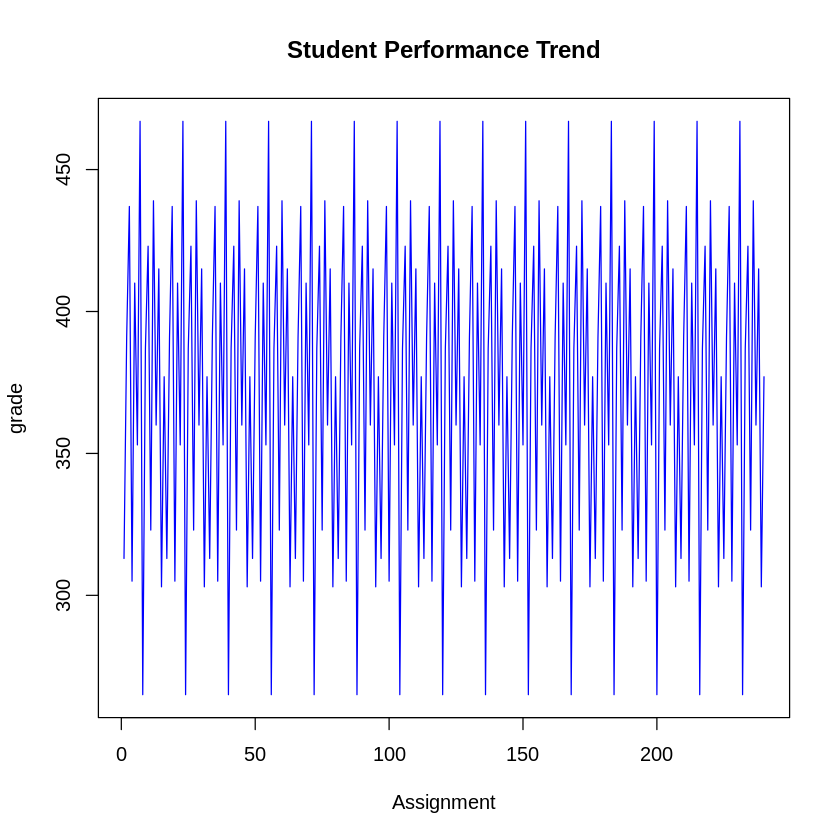

In [ ]:
plot(1:nrow(data),
     data$`_total`,
     type = "l",
     col = "blue",
     main = "Student Performance Trend",
     xlab = "Assignment",
     ylab = "grade")